# 041 — Seasonal Modeling

Comparación de modelos para predecir la **anomalía media de precipitación de los próximos 3 meses**.

Se evalúan:

- **S1 — ENSO seasonal**
- **S2 — ENSO + precipitación reciente**

El período 2018–2025 permanece como **test sellado**.  
La selección se realiza únicamente con validación 2011–2017.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

TRAIN_END = pd.Timestamp("2010-12-01")
VAL_START = pd.Timestamp("2011-01-01")
VAL_END = pd.Timestamp("2017-12-01")
TEST_START = pd.Timestamp("2018-01-01")

TARGET_COLUMN = "target_anomaly_next3m"

print("Proyecto:", PROJECT_ROOT)

Proyecto: /home/gustavo-paredes/Documents/Developer/Yachay/enso-ml


## 1. Definir features

In [2]:
enso_variables = ["nino12", "nino3", "nino34", "nino4", "soi", "tni"]

enso_features = []
for variable in enso_variables:
    enso_features.extend([variable, f"{variable}_ma3"])

seasonal_features = [
    "target_month_sin",
    "target_month_cos",
]

precip_features = [
    "precip_anomaly",
    "precip_anomaly_ma3",
]

feature_columns_s1 = enso_features + seasonal_features
feature_columns_s2 = feature_columns_s1 + precip_features

FEATURE_SETS = {
    "S1_ENSO_SEASONAL": feature_columns_s1,
    "S2_ENSO_PRECIP_SEASONAL": feature_columns_s2,
}

for name, features in FEATURE_SETS.items():
    print(name, "->", len(features), "features")

S1_ENSO_SEASONAL -> 14 features
S2_ENSO_PRECIP_SEASONAL -> 16 features


## 2. Cargar datasets

In [3]:
FILES = {
    "S1_ENSO_SEASONAL": DATA_PROCESSED / "seasonal_model_s1.csv",
    "S2_ENSO_PRECIP_SEASONAL": DATA_PROCESSED / "seasonal_model_s2.csv",
}

DATASETS = {
    name: pd.read_csv(
        path,
        parse_dates=["date", "target_start", "target_center", "target_end"]
    )
    for name, path in FILES.items()
}

for name, data in DATASETS.items():
    print(name, data.shape)

S1_ENSO_SEASONAL (892, 21)
S2_ENSO_PRECIP_SEASONAL (892, 21)


In [4]:
for name, features in FEATURE_SETS.items():
    missing = [f for f in features if f not in DATASETS[name].columns]
    assert not missing, f"{name} tiene features faltantes: {missing}"

print("Columnas requeridas: OK")

Columnas requeridas: OK


## 3. Split temporal por ventana objetivo

In [5]:
def temporal_split(data):
    train = data[
        data["target_end"] <= TRAIN_END
    ].copy()

    val = data[
        (data["target_start"] >= VAL_START)
        & (data["target_end"] <= VAL_END)
    ].copy()

    test = data[
        data["target_start"] >= TEST_START
    ].copy()

    return train, val, test

SPLITS = {}

for name, data in DATASETS.items():
    SPLITS[name] = temporal_split(data)
    train, val, test = SPLITS[name]

    print(
        name,
        "| Train:", len(train),
        "| Validation:", len(val),
        "| Test:", len(test)
    )

S1_ENSO_SEASONAL | Train: 715 | Validation: 82 | Test: 91
S2_ENSO_PRECIP_SEASONAL | Train: 715 | Validation: 82 | Test: 91


In [6]:
reference_val = (
    SPLITS["S1_ENSO_SEASONAL"][1][["target_start", "target_end"]]
    .reset_index(drop=True)
)

for name in SPLITS:
    current_val = (
        SPLITS[name][1][["target_start", "target_end"]]
        .reset_index(drop=True)
    )

    assert current_val.equals(reference_val), (
        f"Las ventanas de validación de {name} no coinciden."
    )

print("Ventanas de validación S1/S2: iguales")

Ventanas de validación S1/S2: iguales


## 4. Métricas y baselines

In [7]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }

_, reference_val_df, _ = SPLITS["S1_ENSO_SEASONAL"]
y_val_reference = reference_val_df[TARGET_COLUMN]

# Baseline climatológico: anomalía futura = 0
climatology_pred = np.zeros(len(y_val_reference))
climatology_metrics = regression_metrics(
    y_val_reference,
    climatology_pred
)

# Baseline de persistencia estacional:
# futuro ≈ media de anomalía de los últimos 3 meses.
persistence_pred = reference_val_df["precip_anomaly_ma3"]
persistence_metrics = regression_metrics(
    y_val_reference,
    persistence_pred
)

baseline_results = pd.DataFrame([
    {
        "experiment": "BASELINE",
        "model": "Climatology",
        **climatology_metrics,
    },
    {
        "experiment": "BASELINE",
        "model": "3M Persistence",
        **persistence_metrics,
    },
])

baseline_results

,experiment,model,MAE,RMSE,R2
0,BASELINE,Climatology,35.974025,48.548817,-0.079826
1,BASELINE,3M Persistence,47.480945,58.613405,-0.573948


## 5. Modelos

In [8]:
def build_models():
    return {
        "Linear Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]),

        "Ridge": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]),

        "Random Forest": RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1,
        ),

        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42,
        ),
    }

## 6. Función común de entrenamiento

In [9]:
def run_experiment(experiment_name):
    features = FEATURE_SETS[experiment_name]
    train, val, test = SPLITS[experiment_name]

    X_train = train[features].copy()
    y_train = train[TARGET_COLUMN].copy()

    X_val = val[features].copy()
    y_val = val[TARGET_COLUMN].copy()

    models = build_models()
    rows = []

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)

        rows.append({
            "experiment": experiment_name,
            "model": model_name,
            **regression_metrics(y_val, val_pred),
        })

    return {
        "results": pd.DataFrame(rows),
        "models": models,
        "train": train,
        "validation": val,
        "test": test,
        "features": features,
    }

## 7. Ejecutar S1 y S2

In [10]:
EXPERIMENT_OUTPUTS = {}

for experiment_name in FEATURE_SETS:
    print("Ejecutando:", experiment_name)
    EXPERIMENT_OUTPUTS[experiment_name] = run_experiment(experiment_name)

print("Listo.")

Ejecutando: S1_ENSO_SEASONAL
Ejecutando: S2_ENSO_PRECIP_SEASONAL
Listo.


## 8. Tabla general de validación

In [11]:
model_results = pd.concat(
    [output["results"] for output in EXPERIMENT_OUTPUTS.values()],
    ignore_index=True
)

all_results = pd.concat(
    [baseline_results, model_results],
    ignore_index=True
)

all_results = (
    all_results
    .sort_values(["RMSE", "MAE"])
    .reset_index(drop=True)
)

all_results

,experiment,model,MAE,RMSE,R2
0,S2_ENSO_PRECIP_SEASONAL,Linear Regression,31.712238,42.515332,0.171891
1,S2_ENSO_PRECIP_SEASONAL,Ridge,31.917916,43.083056,0.149627
2,S1_ENSO_SEASONAL,Linear Regression,33.950089,44.358814,0.098520
3,S1_ENSO_SEASONAL,Ridge,34.227963,44.735006,0.083164
4,S2_ENSO_PRECIP_SEASONAL,Gradient Boosting,34.636057,48.427779,-0.074448
5,BASELINE,Climatology,35.974025,48.548817,-0.079826
6,BASELINE,3M Persistence,47.480945,58.613405,-0.573948
7,S2_ENSO_PRECIP_SEASONAL,Random Forest,43.001902,62.456070,-0.787087
8,S1_ENSO_SEASONAL,Random Forest,46.261518,67.092300,-1.062252
9,S1_ENSO_SEASONAL,Gradient Boosting,49.353404,73.156553,-1.451901


## 9. Mejor modelo de cada experimento

In [12]:
best_by_experiment = (
    model_results
    .sort_values("RMSE")
    .groupby("experiment", as_index=False)
    .first()
    .sort_values("RMSE")
    .reset_index(drop=True)
)

best_by_experiment

,experiment,model,MAE,RMSE,R2
0,S2_ENSO_PRECIP_SEASONAL,Linear Regression,31.712238,42.515332,0.171891
1,S1_ENSO_SEASONAL,Linear Regression,33.950089,44.358814,0.098520


## 10. Gráfico real vs mejores predicciones

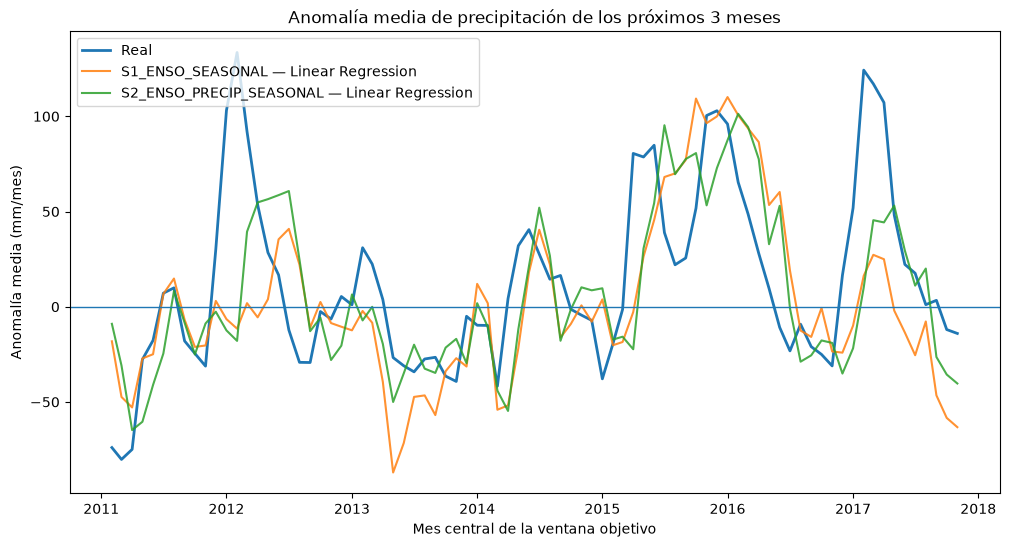

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

val_reference = (
    EXPERIMENT_OUTPUTS["S1_ENSO_SEASONAL"]["validation"]
)

ax.plot(
    val_reference["target_center"],
    val_reference[TARGET_COLUMN],
    label="Real",
    linewidth=2,
)

for experiment_name, output in EXPERIMENT_OUTPUTS.items():
    results = output["results"]

    best_model_name = (
        results
        .sort_values("RMSE")
        .iloc[0]["model"]
    )

    model = output["models"][best_model_name]
    val = output["validation"]
    features = output["features"]

    pred = model.predict(val[features])

    ax.plot(
        val["target_center"],
        pred,
        label=f"{experiment_name} — {best_model_name}",
        alpha=0.85,
    )

ax.axhline(0, linewidth=1)
ax.set_title("Anomalía media de precipitación de los próximos 3 meses")
ax.set_xlabel("Mes central de la ventana objetivo")
ax.set_ylabel("Anomalía media (mm/mes)")
ax.legend()

plt.show()

## 11. Guardar resultados

In [14]:
RESULTS_FILE = DATA_PROCESSED / "seasonal_validation_results.csv"

all_results.to_csv(RESULTS_FILE, index=False)

print("Guardado:", RESULTS_FILE)

Guardado: /home/gustavo-paredes/Documents/Developer/Yachay/enso-ml/data/processed/seasonal_validation_results.csv


## 12. Entrenar con todo lo anterior a 2018 y hacer la prueba

In [15]:
final_data = DATASETS["S2_ENSO_PRECIP_SEASONAL"]

final_train = final_data[
    final_data["target_end"] <= VAL_END
].copy()

final_test = final_data[
    final_data["target_start"] >= TEST_START
].copy()

print("Final train:", final_train.shape)
print("Final test:", final_test.shape)

print(
    "Train targets:",
    final_train["target_start"].min(),
    "->",
    final_train["target_end"].max()
)

print(
    "Test targets:",
    final_test["target_start"].min(),
    "->",
    final_test["target_end"].max()
)

Final train: (799, 21)
Final test: (91, 21)
Train targets: 1950-04-01 00:00:00 -> 2017-12-01 00:00:00
Test targets: 2018-01-01 00:00:00 -> 2025-12-01 00:00:00


In [16]:
features = feature_columns_s2

X_final_train = final_train[features]
y_final_train = final_train[TARGET_COLUMN]

X_test = final_test[features]
y_test = final_test[TARGET_COLUMN]

In [17]:
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

final_model.fit(
    X_final_train,
    y_final_train
)

test_pred = final_model.predict(
    X_test
)

### evaluar test contra los baselines

In [18]:
final_model_metrics = regression_metrics(
    y_test,
    test_pred
)

test_climatology_pred = np.zeros(
    len(y_test)
)

test_climatology_metrics = regression_metrics(
    y_test,
    test_climatology_pred
)

test_persistence_pred = (
    final_test["precip_anomaly_ma3"]
)

test_persistence_metrics = regression_metrics(
    y_test,
    test_persistence_pred
)

In [19]:
final_results = pd.DataFrame([
    {
        "model": "Climatology",
        **test_climatology_metrics,
    },
    {
        "model": "3M Persistence",
        **test_persistence_metrics,
    },
    {
        "model": "S2 Linear Regression",
        **final_model_metrics,
    },
])

final_results.sort_values("RMSE")

,model,MAE,RMSE,R2
1,3M Persistence,38.242818,49.305356,0.255177
2,S2 Linear Regression,40.069239,52.246207,0.163676
0,Climatology,49.737596,64.912517,-0.290987


### grafico final

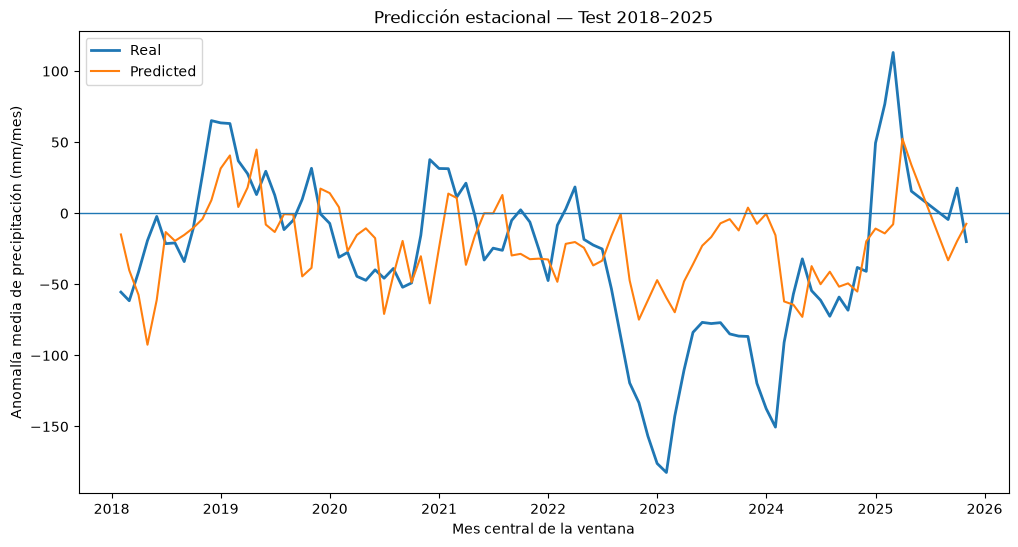

In [20]:
fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    final_test["target_center"],
    y_test,
    label="Real",
    linewidth=2,
)

ax.plot(
    final_test["target_center"],
    test_pred,
    label="Predicted",
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_title(
    "Predicción estacional — Test 2018–2025"
)

ax.set_xlabel(
    "Mes central de la ventana"
)

ax.set_ylabel(
    "Anomalía media de precipitación (mm/mes)"
)

ax.legend()

plt.show()

interpretacion de coeficientes

In [21]:
coefficients = pd.Series(
    final_model
    .named_steps["model"]
    .coef_,
    index=features,
)

coefficient_table = pd.DataFrame({
    "coefficient": coefficients,
    "absolute_coefficient": coefficients.abs(),
})

coefficient_table.sort_values(
    "absolute_coefficient",
    ascending=False
)

,coefficient,absolute_coefficient
nino34_ma3,-114.080027,114.080027
nino34,111.799797,111.799797
nino12_ma3,-108.392412,108.392412
nino3_ma3,99.836455,99.836455
nino4_ma3,97.408785,97.408785
tni,75.188287,75.188287
nino3,-73.749801,73.749801
tni_ma3,21.816303,21.816303
precip_anomaly_ma3,19.887794,19.887794
precip_anomaly,13.317445,13.317445
